### Fun with Gamma Ray Bursts:

Let's look at the latest database of Gamma Ray Bursts.

 - The database can be downloaded at https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt
 - You can find the physical meaning of each variable at https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html 


This edition of "get your hands dirty" is very open ended (we're getting closer and closer to real research...). You have a cool dataset, explore it! Play with the data, apply some of the tecniques we have seen in classes so far, etc. **Be creative! You're discovering**


Some relevant physical questions you might want to tackle include:

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 



In [1]:
import numpy as np
import sklearn
import matplotlib.pyplot as plt

In [2]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names= np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])


In [3]:
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

In [4]:
#Let's start by checking out the T90 and fluence data!
T90=np.array(data[6],dtype=float)
errT90=np.array(data[7],dtype=float)
fluence=np.array(data[9],dtype=float)
errfluence=np.array(data[10],dtype=float)

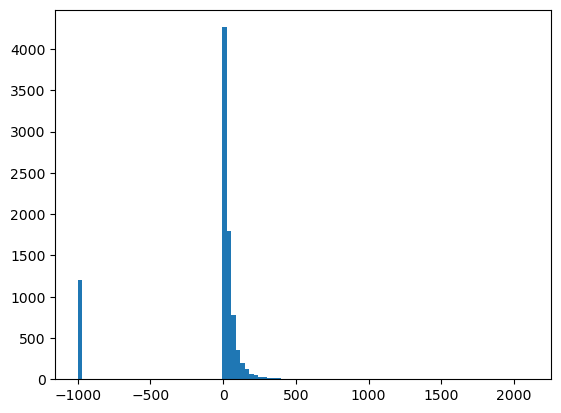

In [5]:
_ = plt.hist(T90, bins = 100)

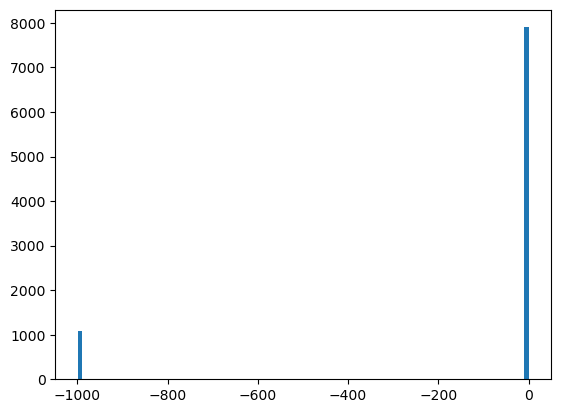

In [6]:
_ = plt.hist(fluence, bins = 100)

In [7]:
#We need to clean our data, there's clearly some missing data set to -999!
errT90 = errT90[T90>0]
T90 = T90[T90>0]
errfluence = errfluence[fluence>0]
fluence = fluence[fluence>0]

Text(0.5, 1.0, 'T90')

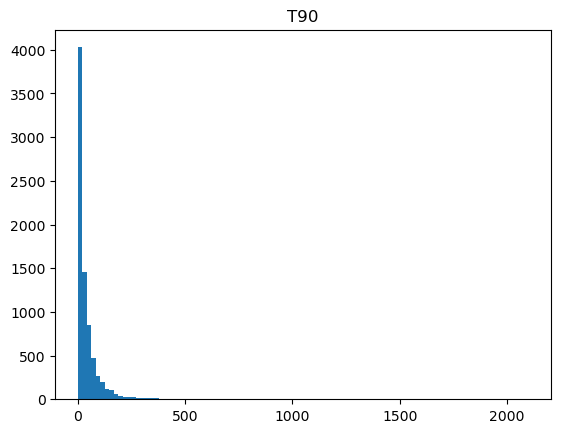

In [8]:
_ = plt.hist(T90, bins = 100)
plt.title('T90')

Text(0.5, 1.0, 'log(T90)')

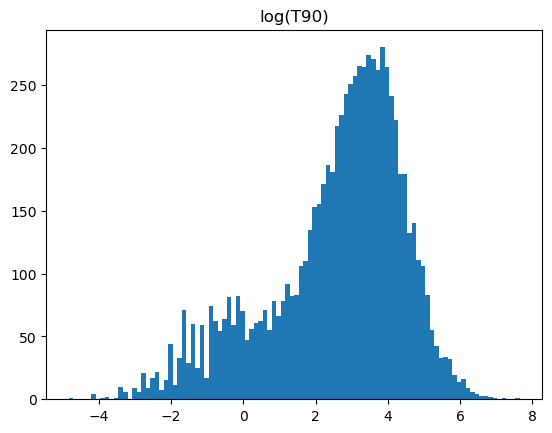

In [9]:
#Better, but let's try with the log of the data! 
_ = plt.hist(np.log(T90), bins = 100)
plt.title('log(T90)')

It seems like we have 2 populations ! Maybe long GRB and short GRB ? 

Text(0.5, 1.0, 'log(fluence)')

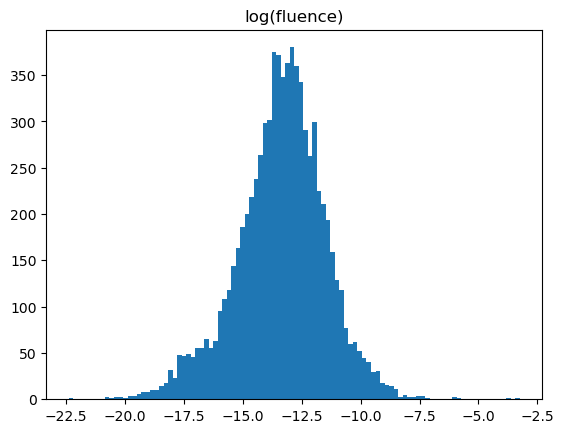

In [10]:
_ = plt.hist(np.log(fluence), bins = 100)
plt.title('log(fluence)')

Here it's less clear! let's focus a bit on T90, starting from a KDE rappresentation.

In [11]:
from sklearn.neighbors import KernelDensity

def kde_sklearn(data, grid, bandwidth = 1.0):
    kde_skl = KernelDensity(bandwidth = bandwidth)
    kde_skl.fit(data[:, np.newaxis]) #, sample_weight = w)
    log_pdf = kde_skl.score_samples(grid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

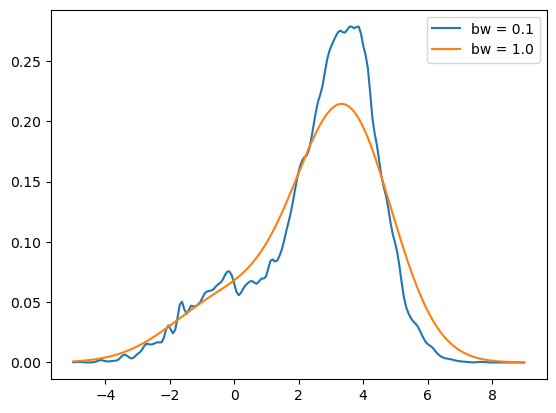

In [12]:
#Let's start by trying 2 differnet bandwidths by hand 
X = np.log(T90)

xgrid =np.linspace(-5,9, 200)
pdf = kde_sklearn(X, xgrid, bandwidth=0.1)
plt.plot(xgrid,pdf, label = 'bw = 0.1')
pdf = kde_sklearn(X, xgrid, bandwidth=1)
plt.plot(xgrid,pdf, label = 'bw = 1.0')
plt.legend()

In [13]:
#Let's now try a  ML approach to choose the bw with CV!
from sklearn.model_selection import GridSearchCV

bwrange = np.linspace(0.01, 1.0, 30) #Test 30 bandwidths from 0.1 to 1.0
K = 3 #Do 3-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) #Try each bandwidth with K-folds
grid.fit(X[:, None]) #Fit the histogram data of log(T90)
h_opt = grid.best_params_['bandwidth']
print('Optimal bandwidth:', h_opt)

Optimal bandwidth: 0.2831034482758621


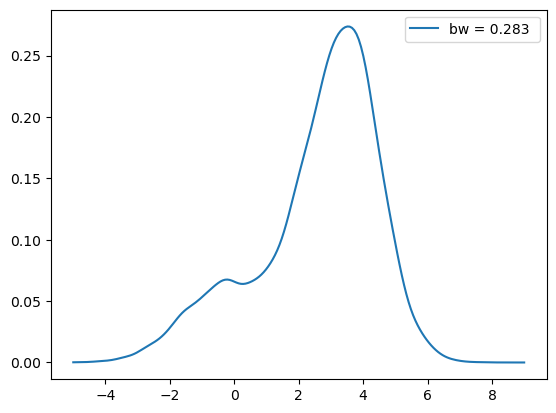

In [14]:
#Plotting the result!
pdf = kde_sklearn(X, xgrid, bandwidth=h_opt)
plt.plot(xgrid,pdf, label = f'bw = {h_opt:.3f} ')
plt.legend()

Cool! Now it's time for some clustering!

In [15]:
from sklearn.cluster import KMeans
from sklearn import preprocessing

clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X[:,None])
centers = clf.cluster_centers_ #location of the clusters
test_labels = clf.predict(xgrid[:,None]) #labels for each of the points
labels = clf.predict(X[:,None])

In [16]:
labels

array([0, 0, 0, ..., 1, 0, 1], dtype=int32)

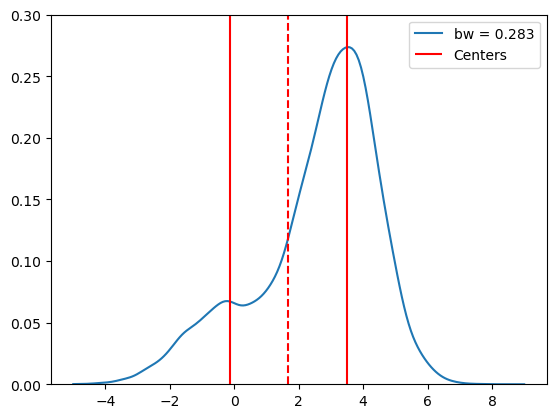

In [17]:
plt.plot(xgrid,pdf, label = f'bw = {h_opt:.3f}')
plt.vlines(centers[:,0], 0, 1, color = 'r', linestyle = '-',label = 'Centers')
plt.ylim(0, 0.3)
plt.legend()

pop1 = X[labels==1]
lim = np.max(pop1)

plt.vlines(lim, 0, 1, color = 'r', linestyle = '--', label = 'Pop 1')
#We dont show the outer boundries as they are right at the end of our distribution!

The division we got seems reasonable, but let's try another clustering algorithm to check! 

In [18]:
from sklearn.cluster import MeanShift

MS = MeanShift(bandwidth=2.4*h_opt, bin_seeding = True)
MS.fit(X[:, None])

MeanShift(bandwidth=0.679448275862069, bin_seeding=True)

In [19]:
ms_centers = MS.cluster_centers_
ms_labels = MS.labels_

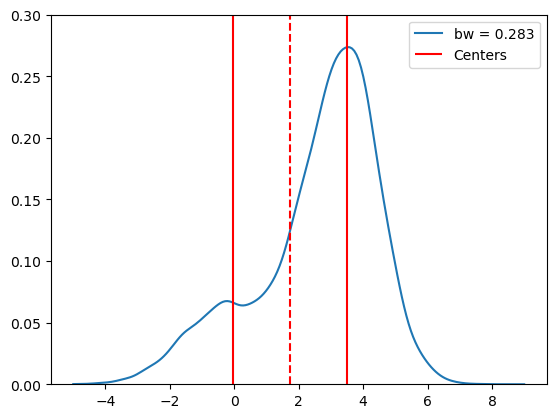

In [20]:
plt.plot(xgrid,pdf, label = f'bw = {h_opt:.3f}')
plt.vlines(ms_centers[:,0], 0, 1, color = 'r', linestyle = '-',label = 'Centers')
plt.ylim(0, 0.3)
plt.legend()

pop1 = X[ms_labels==1]
lim = np.max(pop1)

plt.vlines(lim, 0, 1, color = 'r', linestyle = '--', label = 'Pop 1')
#We dont show the outer boundries as they are right at the end of our distribution!

In [21]:
print(f'Kmeans centers: {centers[1,0], centers[0,0]}')
print(f'MeanShift centers: {ms_centers[1,0], ms_centers[0,0]}')

Kmeans centers: (-0.12492523214868534, 3.4838353694299973)
MeanShift centers: (-0.04253349912015607, 3.5029023968697524)


Cool! We (almost) got the same results ! But this is true only if we tune the bw right when using the MS algorithm, if we were to let it decide it by itself we would end up  with a lot more sub-populations!

In [22]:
shortGRB = T90[labels == 1]
longGRB = T90[labels == 0]

We can now try doing the same with other variables as the fluence we saw before to check if we find 2 sub-populations there too.

#### Fluence:

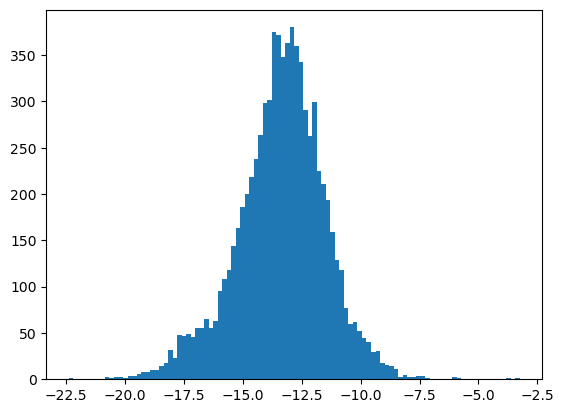

In [23]:
F = np.log(fluence)
_ = plt.hist(F, bins = 100)

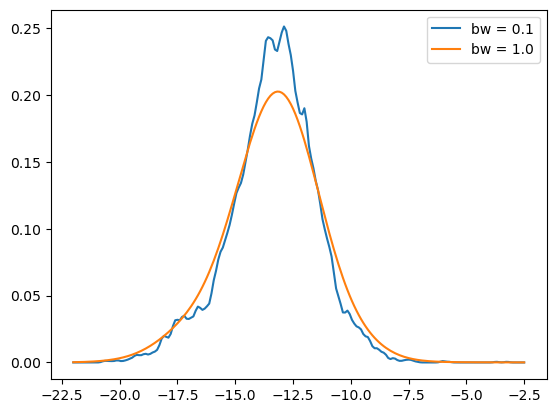

In [24]:
fgrid =np.linspace(-22, -2.5, 200)
pdf = kde_sklearn(F, fgrid, bandwidth=0.1)
plt.plot(fgrid, pdf, label = 'bw = 0.1')
pdf = kde_sklearn(F, fgrid, bandwidth=1.0)
plt.plot(fgrid, pdf, label = 'bw = 1.0')
plt.legend()

In [25]:
bwrange = np.linspace(0.01, 1.5, 40) #Test 40 bandwidths from 0.1 to 1.5
K = 3 #Do 3-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) #Try each bandwidth with K-folds
grid.fit(F[:, None]) 
h_opt = grid.best_params_['bandwidth']
print(h_opt)

1.0033333333333332


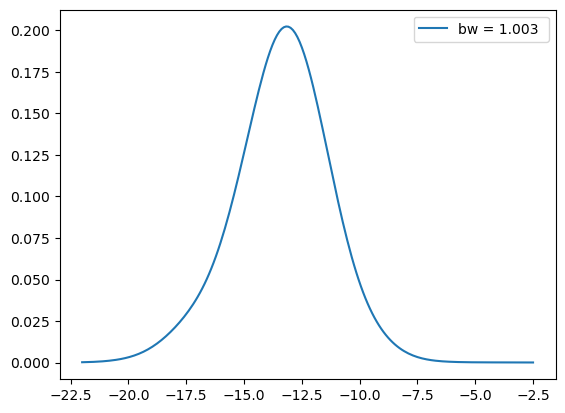

In [26]:
#Plotting the result!
pdf = kde_sklearn(F, fgrid, bandwidth=h_opt)
plt.plot(fgrid, pdf, label = f'bw = {h_opt:.3f} ')
plt.legend()

Doesn't seem like we have to two populations here! Let's  try anyway to check if we find the same classes.

In [27]:
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(F[:,None])
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(F[:,None]) #labels for each of the points

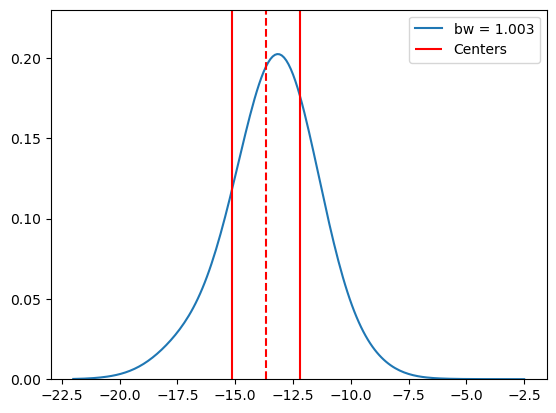

In [28]:
plt.plot(fgrid, pdf, label = f'bw = {h_opt:.3f}')
plt.vlines(centers[:,0], 0, 1, color = 'r', linestyle = '-',label = 'Centers')
plt.ylim(0, 0.23)
plt.legend()

pop1 = F[labels==1]
lim = np.max(pop1)

plt.vlines(lim, 0, 1, color = 'r', linestyle = '--', label = 'Pop 1')
#We dont show the outer boundries as they are right at the end of our distribution!

It does not seem like there's a real distinition between the two sub-populations, let's check other features.

### Redshift:


In [29]:
z=np.array(data[11],dtype=float)
filter90 = np.array(data[6], dtype=float)
z = z[(z > 0) & (filter90>0)]

Text(0.5, 1.0, 'Log(z)')

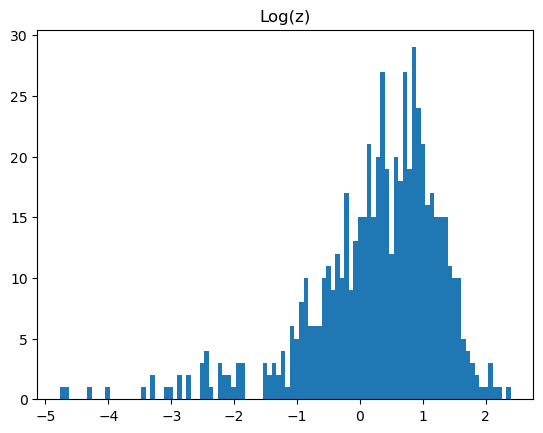

In [30]:
_ = plt.hist(np.log(z), bins = 100)
plt.title('Log(z)')

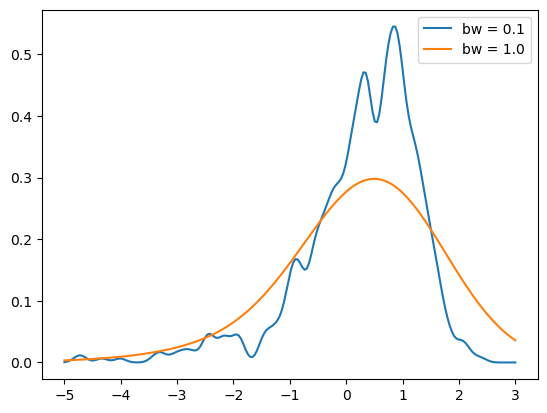

In [31]:
Z = np.log(z)
zgrid =np.linspace(-5, 3, 200)
pdf = kde_sklearn(Z, zgrid, bandwidth=0.1)
plt.plot(zgrid, pdf, label = 'bw = 0.1')
pdf = kde_sklearn(Z, zgrid, bandwidth=1.0)
plt.plot(zgrid, pdf, label = 'bw = 1.0')
plt.legend()

In [32]:
bwrange = np.linspace(0.01, 1.5, 40) # Test 40 bandwidths from 0.01 to 1.5
K = 3 #Do 3-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) #Try each bandwidth with K-folds
grid.fit(Z[:, None])
h_opt = grid.best_params_['bandwidth']
print(h_opt)

0.2774358974358974


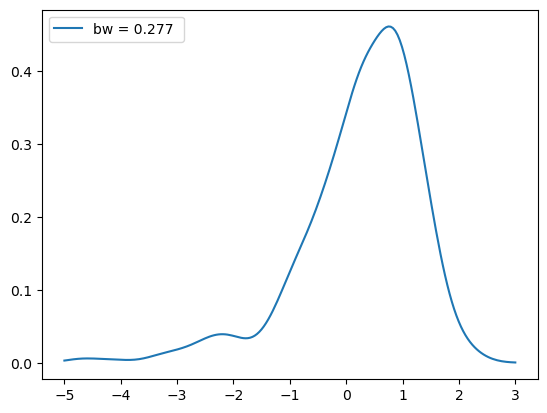

In [33]:
#Plotting the result!
pdf = kde_sklearn(Z, zgrid, bandwidth=h_opt)
plt.plot(zgrid, pdf, label = f'bw = {h_opt:.3f} ')
plt.legend()

It does seem like there something going on! Let's try some clustering!

In [34]:
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(Z[:,None])
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(Z[:,None]) #labels for each of the points
z_centers = centers

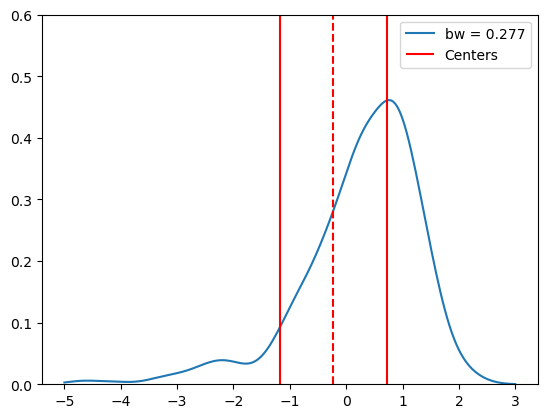

In [36]:
plt.plot(zgrid,pdf, label = f'bw = {h_opt:.3f}')
plt.vlines(centers[:,0], 0, 1, color = 'r', linestyle = '-',label = 'Centers')
plt.ylim(0, 0.6)
plt.legend()

pop1 = Z[labels==1]
lim = np.max(pop1)

plt.vlines(lim, 0, 1, color = 'r', linestyle = '--', label = 'Pop 1')
#We dont show the outer boundries as they are right at the end of our distribution!

We can now try to see if the classes found here have something in common with the ones given by T90:

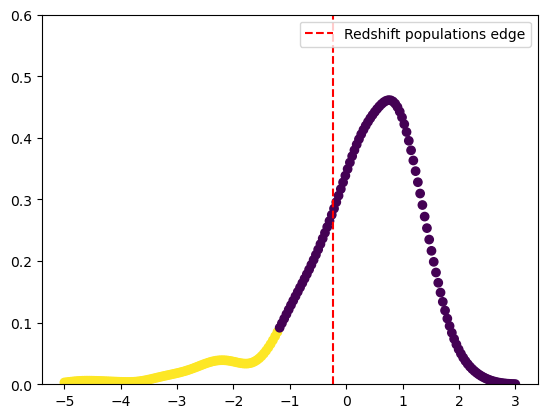

In [38]:
plt.scatter(zgrid, pdf, c = test_labels)
#plt.vlines(centers[:,0], 0, 1, color = 'r', linestyle = '-',label = 'Centers')
plt.ylim(0, 0.6)

pop1 = Z[labels==1]
lim = np.max(pop1)

plt.vlines(lim, 0, 1, color = 'r', linestyle = '--', label = 'Redshift populations edge')
plt.legend()
#We dont show the outer boundries as they are right at the end of our distribution!

The colors show the two different sub-populations as found by T90. Even if there's no perfect match, it does seem like there could be some correlation between the two!

### Sky position:

In [39]:
ra=np.array(data[3],dtype=float)
dec=np.array(data[4],dtype=float)

Text(0, 0.5, 'dec')

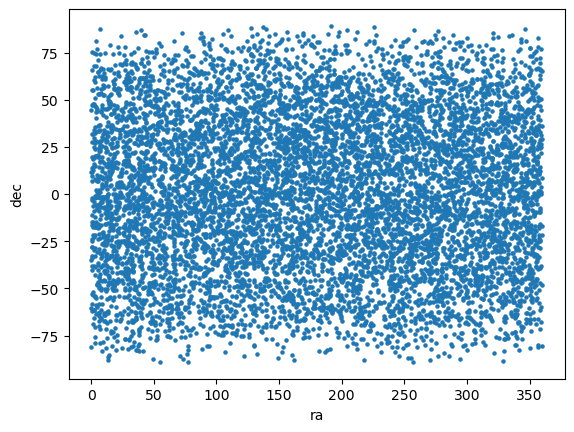

In [40]:
plt.scatter(ra, dec, s = 5)
plt.xlabel('ra')
plt.ylabel('dec')
#It seems like everything is distributed in an homogeneous way! 

## 2D clustering:

Ok, so we've seen that redshift and T90 are the two variables that show clearer sub-populations, 
let's try to use both to classify our GRBs!

In [41]:
#Taking only the events for which we have both:
t90 = np.array(data[6], dtype=float)
z = np.array(data[11], dtype=float)
filt_t90 = t90[(t90>0) & (z>0)]
filt_z = z[(t90>0) & (z>0)]

Text(0, 0.5, 'log(z)')

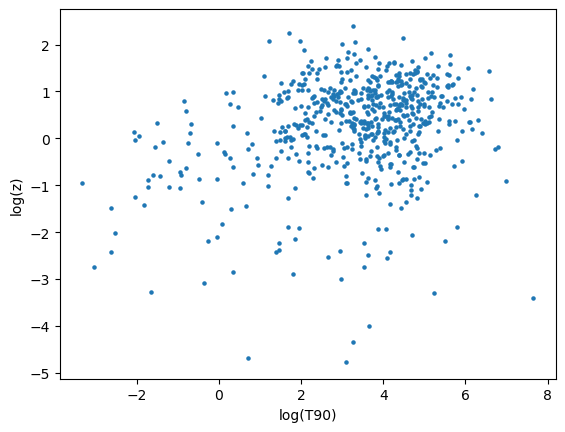

In [42]:
X = np.zeros((len(filt_t90),2))
X[:,0] = np.log(filt_t90)
X[:,1] = np.log(filt_z)
plt.scatter(X[:,0], X[:,1], s=5)
plt.xlabel('log(T90)')
plt.ylabel('log(z)')

There's no clear sub-populations, but let's try anyway!

In [43]:
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

Text(0, 0.5, 'log(z)')

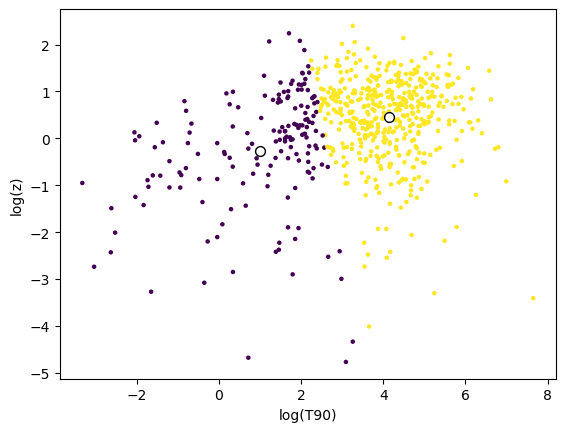

In [44]:
plt.scatter(X[:,0], X[:,1], s=5, c = labels)
plt.scatter(centers[:,0], centers[:,1], s = 50, c = 'w', edgecolor = 'k')
plt.xlabel('log(T90)')
plt.ylabel('log(z)')

In [45]:
old_t90centers = np.array([3.488058243749271, -0.12734703024875182]).reshape(-1,1)
old_zcenters = z_centers
old_centers = np.hstack([old_t90centers, old_zcenters])

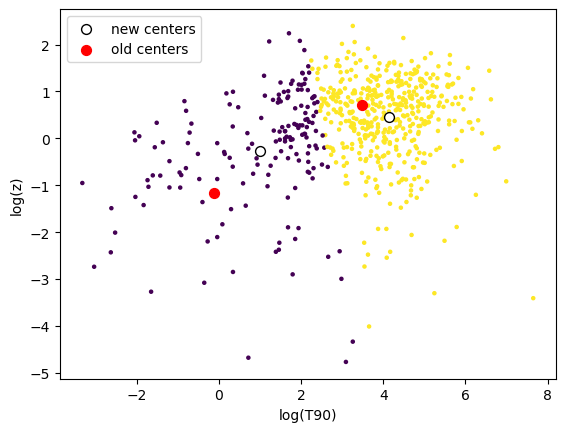

In [46]:
plt.scatter(X[:,0], X[:,1], s=5, c = labels)
plt.scatter(centers[:,0], centers[:,1], s = 50, c = 'w', edgecolor = 'k', label ='new centers')
plt.scatter(old_centers[:,0], old_centers[:,1], s = 50, c = 'r', label = 'old centers')
plt.xlabel('log(T90)')
plt.ylabel('log(z)')
plt.legend()

We are not too far away! We also have to consider that now we have drastically less points than before.

## Testing out-liers:

Going back to our T90 analysis, to test how clustering algorithms behave with outliers, we'll add some points with very high T90 values:

In [47]:
outliers = np.full(100, 2099.0)
bad_data = np.concatenate([T90, outliers])

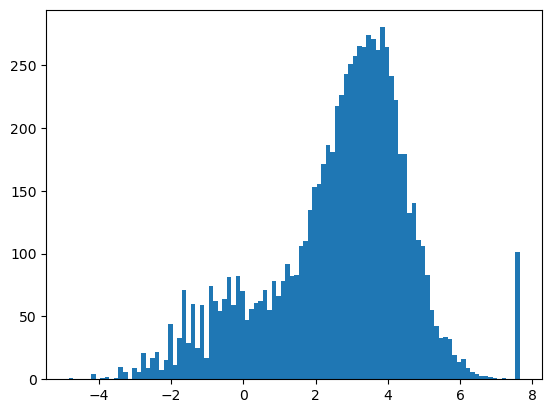

In [48]:
_ = plt.hist(np.log(bad_data), bins = 100)

In [49]:
X = np.log(bad_data)
xgrid =np.linspace(-5, 9, 200)

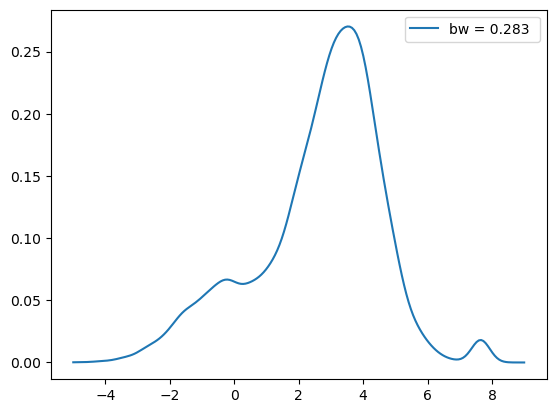

In [50]:
#Plotting the result!
pdf = kde_sklearn(X, xgrid, bandwidth=0.283)
plt.plot(xgrid, pdf, label = f'bw = 0.283 ')
plt.legend()

In [51]:
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X[:, None])
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X[:, None]) #labels for each of the points

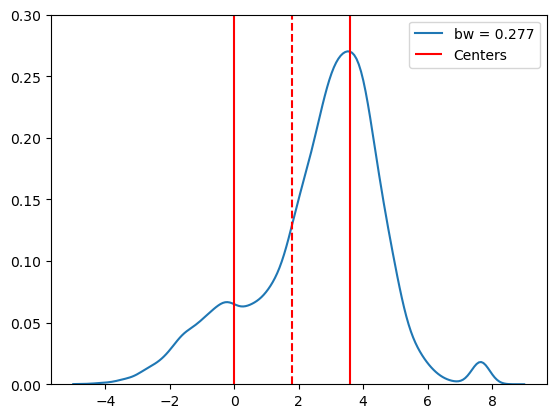

In [53]:
plt.plot(xgrid,pdf, label = f'bw = {h_opt:.3f}')
plt.vlines(centers[:,0], 0, 1, color = 'r', linestyle = '-',label = 'Centers')
plt.ylim(0, 0.3)
plt.legend()

pop1 = X[labels==1]
lim = np.min(pop1)

plt.vlines(lim, 0, 1, color = 'r', linestyle = '--', label = 'Pop 1')
#We dont show the outer boundries as they are right at the end of our distribution!

Using K-Mean there's no much difference with or without the outliers!

But let's see with MeanShift

In [54]:
from sklearn.cluster import MeanShift

MS = MeanShift(bandwidth=2.4*h_opt, bin_seeding = True)
MS.fit(X[:, None])

MeanShift(bandwidth=0.6658461538461538, bin_seeding=True)

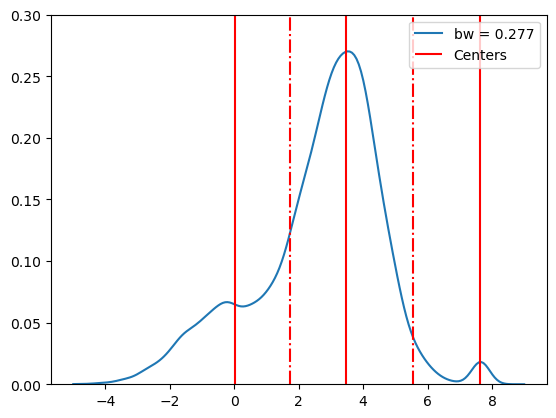

In [55]:
ms_centers = MS.cluster_centers_
ms_labels = MS.labels_

plt.plot(xgrid,pdf, label = f'bw = {h_opt:.3f}')
plt.vlines(ms_centers[:,0], 0, 1, color = 'r', linestyle = '-',label = 'Centers')
plt.ylim(0, 0.3)
plt.legend()

pop1 = X[ms_labels==1]
pop2 = X[ms_labels==2]
lim = np.max(pop1)
lim2 = np.min(pop2)

plt.vlines(lim, 0, 1, color = 'r', linestyle = '-.', label = 'Pop 1')
plt.vlines(lim2, 0, 1, color = 'r', linestyle = '-.', label = 'Pop 1')
#We dont show the outer boundries as they are right at the end of our distribution!

We got a whole new population ! Mean-Shift is more sensitive to outliers as the number of cluster is determined by the algorithm itself. With K-means the error would be 'caused' by us setting the number of cluster to 3 as we see the small bump created by the outliers data.  